# When California burns, does the market torch the utilities and insurers? 🔥📉
### The "fire-season trade" — a story that's *half* true, in the most misleading way

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Seasonal%3F: Busted](https://img.shields.io/badge/Seasonal%3F-Busted-8b949e?style=flat-square)

Every California fire season, the same trade makes the rounds: a big wildfire breaks out, so *sell* (or short) the exposed names — the utility whose power lines might have sparked it (PG&E, Edison) and the property insurers left holding the claims (Allstate, Travelers, Mercury, Chubb) — and underweight the whole basket heading into fire season. And there's a real, brutal precedent: PG&E literally went **bankrupt** in 2019 over its wildfire liability, and Edison cratered when its equipment became the suspect in the January 2025 Los Angeles fires.

So the folklore *feels* obviously right. We test the strong, tradable version of it on **14 of the biggest California wildfires since 2003** — and find that the obvious-looking truth hides three things that quietly kill the trade.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo, the bootstrap/jackknife outlier autopsy and the seasonal test? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Note, stated plainly.** The "short it" test near the end is a clinical statistical exercise on public market data — a wildfire is a human tragedy first; this is a test of whether a *trading pattern* exists, not a suggestion about how to profit from disaster. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from wildfire_season import data, strategy as st

FIRES = data.fire_table()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    SERIES = data.load_real()
    AR_SPY = st.abnormal_returns(st.daily_returns(SERIES["SPY"]))
    AR_BK = st.abnormal_returns(st.basket_returns(SERIES, data.BASKET_TICKERS))
    AR_UTIL = st.abnormal_returns(st.basket_returns(SERIES, data.UTIL_TICKERS))
    AR_INS = st.abnormal_returns(st.basket_returns(SERIES, data.INS_TICKERS))
    NAV_BK = st.basket_nav(SERIES, data.BASKET_TICKERS)
else:
    SERIES = AR_SPY = AR_BK = AR_UTIL = AR_INS = NAV_BK = None
print("real cache present:", HAVE_REAL, "| fires in table:", len(FIRES),
      "| utility-linked:", int(FIRES["utility_linked"].sum()))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_events': 14, 'n_util_linked': 7, 'n_nonutil': 7, 'cal_lo': '2003-10-25', 'cal_hi': '2025-01-07', 'day0_mean_bps': -22.77, 'day0_t': -0.92, 'hit_down': 9, 'hit_n': 14, 'hit_pct': 64.3, 'wilson': (38.8, 83.7), 'placebo_mean_bps': -0.31, 'placebo_sd_bps': 36.04, 'placebo_p': 0.242, 'placebo_draws': 20000, 'event': {-1: (-57.05, 0.0, -2.17), 0: (-22.77, -22.77, -0.92), 1: (-74.35, -97.11, -1.38), 2: (-149.74, -246.86, -1.7), 3: (-66.23, -313.09, -1.18), 4: (-7.84, -320.92, -0.11), 5: (33.22, -287.71, 0.51)}, 'rev_mean_bps': -264.94, 'rev_t': -1.41, 'rev_ci': (-657.7, 41.4), 'rev_jk_below2': 14, 'rev_jk_n': 14, 'rev_jk_tmin': -1.61, 'rev_jk_tmax': -0.98, 'util_mean_bps': -704.11, 'util_t': -1.51, 'ins_mean_bps': -45.35, 'ins_t': -0.6, 'leg_diff_bps': -658.76, 'leg_diff_t': -1.54, 'ul_n': 7, 'ul_day0_bps': -22.27, 'ul_day0_t': -0.47, 'ul_rev_bps': -1596.35, 'ul_rev_t': -1.96, 'ul_jk_below2': 5, 'ul_jk_n': 7, 'ed_basket_bps': -264.94, 'ed_spy_bps': 24.86, 'ed_diff_bps': -289.8, 'ed_t': -1.71, 'ed_n': 14, 'seas_in_bps': 1.809, 'seas_out_bps': -1.777, 'seas_gap_bps': 3.586, 'seas_t': 1.019, 'seas_p': 0.297, 'timer': {5: (227.91, 30.9, 211.96, 1.19, 57), 10: (197.69, 141.15, 175.79, 1.16, 57), 21: (116.92, 11.37, 81.92, 0.45, 43)}, 'syn_null_mean': -0.09, 'syn_null_sd': 0.96, 'syn_null_fire': 1, 'syn_planted_t': -10.92, 'syn_planted_bps': -298.1, 'fp_eix': '62b4a2a1757b', 'fp_pcg': '759d993391f0', 'fp_all': '7898cdc31849', 'fp_trv': '3a070b43af0e', 'fp_mcy': 'c95d75857b2a', 'fp_cb': '36b3badbd526', 'fp_spy': '1ecb87f843e4'}


real cache present: True | fires in table: 14 | utility-linked: 7


## The answer first

| Question | Answer |
|---|---|
| Does the basket drop the day a fire breaks out? | **No — not detectably.** The utility+insurer basket moves **-22.77 bps** on the average ignition day (*t* = -0.92) — a random calendar beats that about **24%** of the time. |
| So where's the famous PG&E-style crater? | **In the days *after* the fire, not on it** — and only for the *utilities*, only on the handful of fires their own equipment caused. It's a slow **liability** repricing ("our lines started it"), not a same-day market flinch. |
| Do the insurers get hit too? | **Barely.** The insurer half of the basket gives up just **-0.45%** over the week after a fire (*t* = −0.60) — they're diversified and reinsured; one state's fire is a footnote. |
| Is there a "sell in July" fire-season seasonal? | **No — it's the wrong sign.** The basket does *slightly better* inside the July→December fire window than the rest of the year. |
| Could you trade it? | **No edge — a lottery.** Shorting the basket on the fire headline pays *on average* only because of two bankruptcy-scale jackpots; the *typical* fire barely moves it, and by three weeks you lose more often than you win. |

> The intuitive truth — "the fire destroyed the stock" — is real for a *couple* of megafires, but it's a delayed, utility-specific liability event, not the same-day, basket-wide, seasonal, tradable pattern the story sells.

## 1 · The claim

> *"California fire season is a recurring, tradable risk event. When a major wildfire ignites, sell the utility whose lines may have started it and the insurers who'll pay the claims — and stay underweight the basket through the summer-to-autumn fire window."*

This one has real teeth, unlike most folklore we test. California's **inverse-condemnation** doctrine makes a utility strictly liable for damage its equipment causes — *even without negligence* — so a fire traced to a power line is a direct, enormous, near-automatic hit to that utility's equity. PG&E's 2019 Chapter 11 (≈ $30 bn of fire liability) and Edison's January 2025 plunge are the proof the mechanism is real. The question isn't *whether* a utility-caused megafire can wreck the stock — it obviously can — it's whether that adds up to a **systematic, tradable** pattern across fires.

## 2 · So what?

If the strong version held, you'd have a clean, repeatable playbook: short the basket on every ignition headline, and lighten up every July. That's a real edge in a sector most investors hold for its *safety* (utilities and insurers are classic defensive, dividend names). So we ask four things: does the basket drop on the ignition day, does the damage (wherever it is) show up in insurers or just utilities, is the fire *season* itself a bad time to own the basket, and does shorting the headline actually pay after costs and borrow?

## 3 · How would we even know?

- **The calendar.** **14** major California wildfires from 2003-10-25 to 2025-01-07 — the front-page fires any Californian would name — each tagged by whether a utility's equipment (likely) caused it (**7** utility-linked, **7** not).
- **The comparison.** The basket's return on the first tradable session after each ignition vs. every other day, and vs. a random 14-day calendar drawn 20,000 times.
- **The split.** Utilities (EIX/PCG) vs. insurers (ALL/TRV/MCY/CB) — which half actually moves?
- **The seasonal.** Is the July→December fire window a systematically worse time to own the basket than the rest of the year?
- **The trade.** Short the basket at the ignition close, hold a few weeks, pay costs *and* borrow — do you beat zero, and how often do you actually win?

## 4 · The teardown — let's actually look

**First, the ignition day.** If a fire is a market event for the basket, the day it breaks should show it.

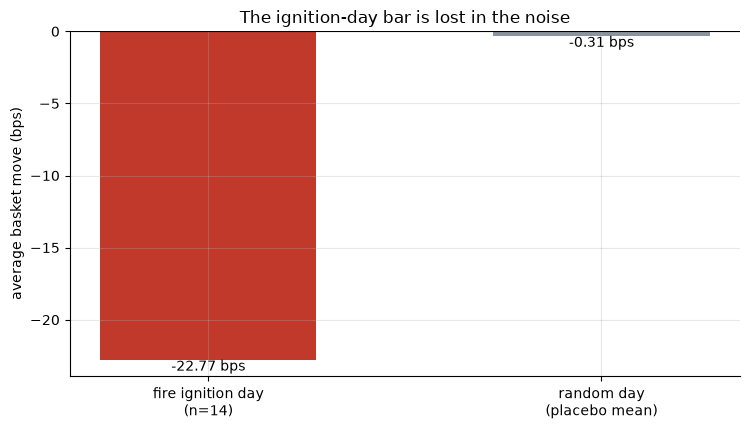

ignition day -22.77 bps vs random day -0.31 bps


In [2]:
if HAVE_REAL:
    d0 = st.day0_stats(AR_BK, FIRES['date'], pre=1, post=5)
    day0_bps = d0['mean'] * 1e4
else:
    day0_bps = R['day0_mean_bps']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['fire ignition day\n(n=14)', 'random day\n(placebo mean)'],
       [day0_bps, R['placebo_mean_bps']], color=[RED, GREY], width=.55)
for i, v in enumerate([day0_bps, R['placebo_mean_bps']]):
    ax.annotate(f'{v:+.2f} bps', (i, v), ha='center',
                va='top' if v < 0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('average basket move (bps)')
ax.set_title('The ignition-day bar is lost in the noise')
plt.tight_layout(); plt.show()
print(f'ignition day {day0_bps:+.2f} bps vs random day {R["placebo_mean_bps"]:+.2f} bps')

**-22.77 bps** on the average ignition day — the right sign, but tiny, and a random 14-day calendar produces a dip this big about **24%** of the time. On the *day* the fire breaks, the market doesn't yet know whose fault it is — so it doesn't move. That's the first clue: whatever damage there is doesn't happen on day 0.

**Next, the week around the fire.** Watch where the drop actually lives.

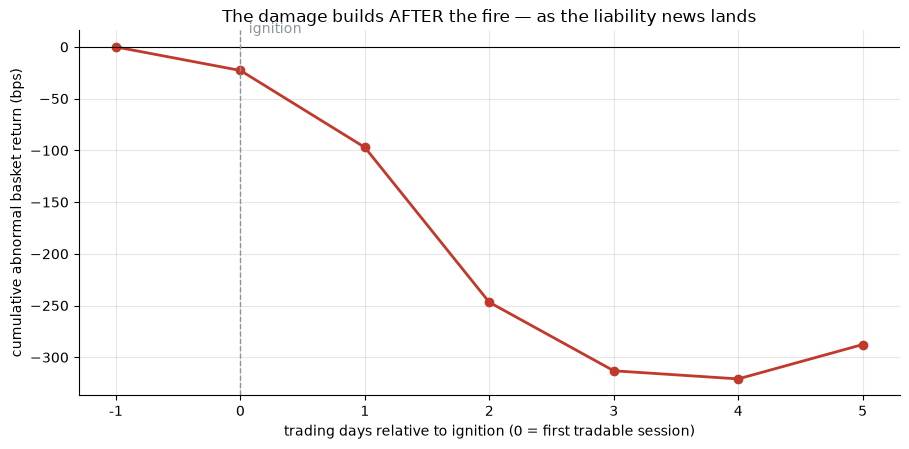

CAR by offset (bps): {-1: 0.0, 0: -22.8, 1: -97.1, 2: -246.9, 3: -313.1, 4: -320.9, 5: -287.7}


In [3]:
if HAVE_REAL:
    cp = st.car_path_stats(AR_BK, FIRES['date'], pre=1, post=5)
    ks, cars = list(cp.index), list(cp['car'] * 1e4)
else:
    ks = sorted(R['event']); cars = [R['event'][k][1] for k in ks]
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.plot([str(k) for k in ks], cars, marker='o', color=RED, lw=2)
ax.axhline(0, c='k', lw=.8)
ax.axvline('0', c=GREY, ls='--', lw=1)
ax.annotate('ignition', ('0', 0), textcoords='offset points', xytext=(6, 10),
            color=GREY)
ax.set_xlabel('trading days relative to ignition (0 = first tradable session)')
ax.set_ylabel('cumulative abnormal basket return (bps)')
ax.set_title('The damage builds AFTER the fire — as the liability news lands')
plt.tight_layout(); plt.show()
print('CAR by offset (bps):', {k: round(c, 1) for k, c in zip(ks, cars)})

There it is: the line slides *downhill after* day 0, bottoming around **−3.2%** a few sessions later. That shape — flat on the day, sinking over the next week — is the fingerprint of a **fundamental** repricing: markets spend the following days working out *whose equipment started it* and *how big the liability is*. It is not a mood/sentiment flinch on the news.

**Now the crucial split.** Utilities or insurers — who's actually taking the hit?

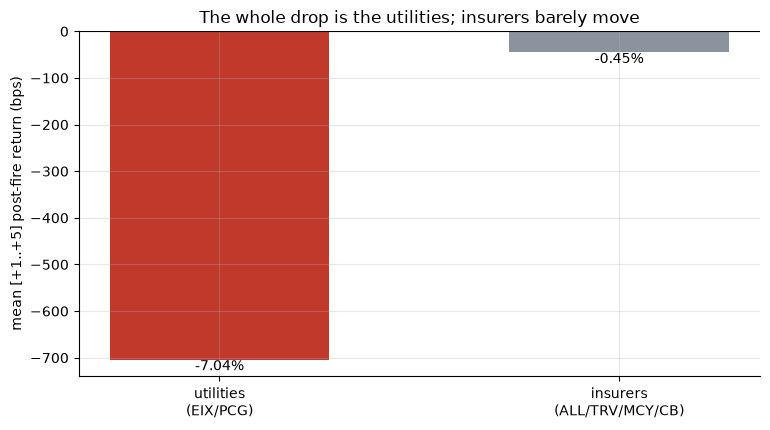

utility leg -7.04%  vs  insurer leg -0.45% (post-fire week)


In [4]:
if HAVE_REAL:
    lc = st.leg_compare(AR_UTIL, AR_INS, FIRES['date'], pre=1, post=5, window='post')
    util_b, ins_b = lc['util_mean'] * 1e4, lc['ins_mean'] * 1e4
else:
    util_b, ins_b = R['util_mean_bps'], R['ins_mean_bps']
fig, ax = plt.subplots(figsize=(7.8, 4.4))
ax.bar(['utilities\n(EIX/PCG)', 'insurers\n(ALL/TRV/MCY/CB)'],
       [util_b, ins_b], color=[RED, GREY], width=.55)
for i, v in enumerate([util_b, ins_b]):
    ax.annotate(f'{v/100:+.2f}%', (i, v), ha='center', va='top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean [+1..+5] post-fire return (bps)')
ax.set_title('The whole drop is the utilities; insurers barely move')
plt.tight_layout(); plt.show()
print(f'utility leg {util_b/100:+.2f}%  vs  insurer leg {ins_b/100:+.2f}% (post-fire week)')

The utilities give up **-7.04%** over the week after a fire; the insurers, **-0.45%** — essentially nothing. That kills half the folklore outright: property insurers are national, diversified and reinsured, so even a record California fire loss is a footnote to their book. The "trade" is really just *one thing* — the two California utilities' liability risk.

**The seasonal.** Is fire season itself a bad time to own the basket?

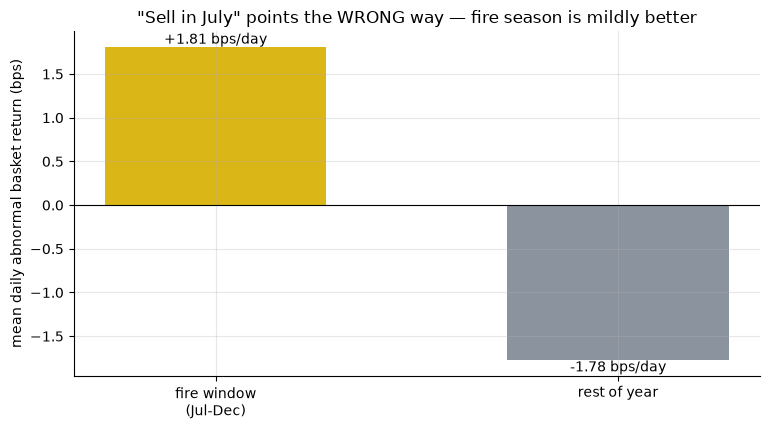

fire window +1.81 bps/day vs rest -1.78 bps/day


In [5]:
if HAVE_REAL:
    seas = st.seasonal_test(AR_BK, fire_months=data.FIRE_MONTHS)
    inb, outb = seas['in_mean'] * 1e4, seas['out_mean'] * 1e4
else:
    inb, outb = R['seas_in_bps'], R['seas_out_bps']
fig, ax = plt.subplots(figsize=(7.8, 4.4))
ax.bar(['fire window\n(Jul-Dec)', 'rest of year'], [inb, outb],
       color=[AMBER, GREY], width=.55)
for i, v in enumerate([inb, outb]):
    ax.annotate(f'{v:+.2f} bps/day', (i, v), ha='center',
                va='bottom' if v > 0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean daily abnormal basket return (bps)')
ax.set_title('"Sell in July" points the WRONG way — fire season is mildly better')
plt.tight_layout(); plt.show()
print(f'fire window {inb:+.2f} bps/day vs rest {outb:+.2f} bps/day')

The "sell in July for California risk" seasonal doesn't just fail to show up — it points the **wrong way**. Utilities are defensive, dividend-rich names that tend to do *well* when the broad market gets jittery in the autumn, so the basket's fire-window return is if anything slightly *positive*. The calendar simply doesn't price fire risk in advance.

**Finally, the trade.** Short the basket on the fire headline — does it pay?

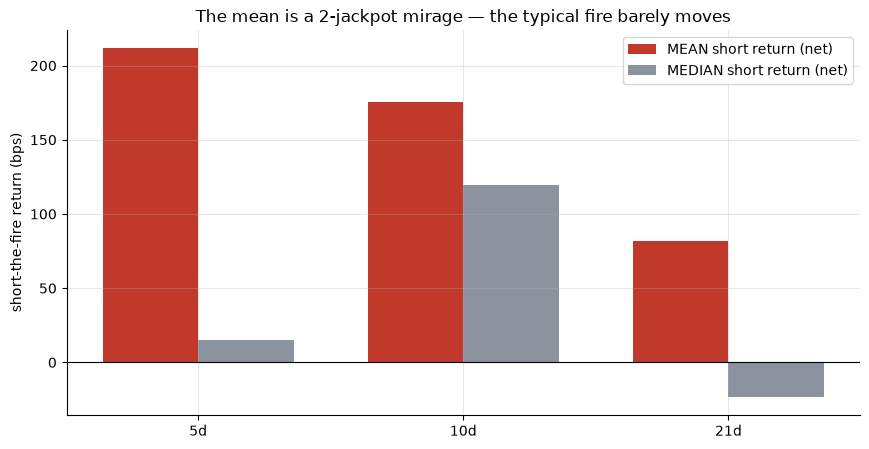

net mean (bps): {5: 212.0, 10: 175.8, 21: 81.9}
net median (bps): {5: 14.9, 10: 119.2, 21: -23.6}
win rate (%): {5: 57, 10: 57, 21: 43}


In [6]:
if HAVE_REAL:
    holds = [5, 10, 21]; means = []; meds = []; wins = []
    for h in holds:
        lg = st.fire_timer(NAV_BK, FIRES['date'], hold=h, cost_bps=5.0,
                           borrow_bps_annual=300.0)
        s = st.summarize_timer(lg, col='ret_net')
        means.append(s['mean_bps']); meds.append(s['median_bps'])
        wins.append(s['win_rate'] * 100)
else:
    holds = sorted(R['timer'])
    means = [R['timer'][h][2] for h in holds]
    meds = [R['timer'][h][1] for h in holds]
    wins = [R['timer'][h][4] for h in holds]
fig, ax = plt.subplots(figsize=(8.8, 4.6))
x = np.arange(len(holds)); w = 0.36
ax.bar(x - w/2, means, width=w, color=RED, label='MEAN short return (net)')
ax.bar(x + w/2, meds, width=w, color=GREY, label='MEDIAN short return (net)')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in holds])
ax.set_ylabel('short-the-fire return (bps)')
ax.set_title('The mean is a 2-jackpot mirage — the typical fire barely moves')
ax.legend(); plt.tight_layout(); plt.show()
print('net mean (bps):', dict(zip(holds, [round(v,1) for v in means])))
print('net median (bps):', dict(zip(holds, [round(v,1) for v in meds])))
print('win rate (%):', dict(zip(holds, [round(v) for v in wins])))

Look at the gap between the two bars. At a 5-day hold the short's *mean* is **+212 bps** but its *median* is only **+31 bps** — the average is propped up entirely by two bankruptcy-scale jackpots (PG&E's Camp Fire, Edison's Eaton Fire). The *typical* fire barely moves the basket, you're paying borrow to stay short a basket of defensive dividend stocks, and by three weeks the win rate falls to **43%** — you lose more often than you win. This is a negative-carry bet on a rare, un-timeable disaster, not an edge.

## 5 · The verdict

- **Signal — None.** The ignition day is flat (**-22.77 bps**, *t* = -0.92, placebo *p* = 0.24). The real post-fire crater is a delayed, utility-only, liability repricing concentrated in two megafires — it doesn't clear the desk's significance bar even at its strongest, and insurers barely move.
- **Tradability — Mirage.** Shorting the headline is a 2-jackpot lottery: positive mean, tiny median, never significant net of borrow, negative win-rate by three weeks.
- **"A sell-in-July fire-season seasonal?" — Busted.** The fire window is if anything mildly *positive* for the basket. The calendar doesn't price fire risk ahead of time.

## 6 · Going further 🚪

- **This doesn't deny that utility-caused megafires wreck utility stocks.** They obviously do — PG&E went bankrupt. The honest finding is narrower and more useful: that damage is a *fundamental liability event*, it lands in the *days after* ignition (not on it), it's *utility-only* (not insurers), it's *concentrated* in a couple of fires, and it is *not* a same-day, seasonal, or costable trading pattern.
- **Where a real edge might hide:** conditioning on *cause attribution* (shorting only once a utility's equipment is publicly named as the suspect — but that news is already in the price), or single-name utility options around known ignition-investigation catalysts, rather than a blunt basket-and-calendar rule.
- **Sibling studies:** [707-plane-crash-effect](../../707-plane-crash-effect/) (the mirror image — a *sentiment* claim on a broad index, also busted), and [313-geopolitical-shock](../../313-geopolitical-shock/) (hardcoded shock calendar, same placebo design).

*Think cause-attribution timing or single-name options catch what a basket-and-calendar rule misses? Show it — out-of-sample, after costs and borrow — then we'll talk.*